# CARDIOVASCULAR RISK SCREENING FOR KENYANS

# BUSINESS UNDERSTANDING SECTION

# CARDIOVASCULAR RISK SCREENING FOR KENYANS: 
# A Machine Learning Approach to CVD Prevention

## 1. THE REAL-WORLD PROBLEM

Cardiovascular disease (CVD)-including coronary heart disease and heart attack 
(myocardial infarction)-is the LEADING CAUSE OF DEATH GLOBALLY and a rapidly 
growing crisis in Kenya.

### KEY FACTS:
- CVD accounts for ~30% of all deaths in Kenya (WHO, Kenya NCD Strategic Plan)
- Driven by modifiable risk factors: tobacco use, physical inactivity, obesity, 
  diabetes, hypertension
- Rapid urbanization - shift to processed, high-sodium, high-sugar foods
- Limited access to preventive screening at community level
- Most Kenyans interact with health system only when acutely ill
- Resource constraints: 47 county health departments must allocate NCD budgets 
  efficiently
### THE GAP THIS PROJECT ADDRESSES:

No widely available, simple, data-driven CVD risk screening tool exists for Kenya 
that meets all these criteria:

1. Uses READILY COLLECTIBLE indicators (no lab tests required)
   - Self-reported behavioral & clinical factors
   - Can be administered by Community Health Volunteers (CHVs)
   
2. Provides INTERPRETABLE risk scores (not a black box)
   - Explains which factors are driving risk
   - Actionable for behavior change counseling
   
3. Is DEPLOYABLE at scale
   - Web-based calculator for clinics, county departments
   - Mobile-friendly for CHVs on household visits
   - Integrates with existing HMIS data streams

4. Allows TARGETING of interventions
   - Identify high-risk populations within counties
   - Guide prevention program design
   - Support insurance companies in wellness benefits


# WHY CDC BRFSS AS A PROXY DATASET


### METHODOLOGICAL JUSTIFICATION FOR USING U.S. DATA

Kenya does NOT yet have a population-scale behavioral risk factor survey of 
sufficient size and richness for machine learning. However, the CDC BRFSS 2024 
dataset is an IDEAL METHODOLOGICAL PROXY because:

1. SAME RISK FACTOR UNIVERSE
   - Smoking (100+ cigarettes, current frequency)
   - BMI / obesity (height, weight)
   - Physical activity (exercise frequency)
   - Diabetes (self-reported diagnosis)
   - Hypertension (self-reported diagnosis)
   - High cholesterol (self-reported diagnosis)
   - General health status
   - Mental health & stress
   
   These are THE SAME factors driving CVD in Kenya (per Kenya STEPwise data).

2. LARGE, REPRESENTATIVE SAMPLE
   - 457,670 respondents (2024 data)
   - Adequate for training ML models with class imbalance
   - Sufficient for cross-validation and subgroup analysis
3. CLEAR OUTCOME VARIABLE
   - CVDINFR4: "Ever told you had a heart attack?"
   - Direct match to our clinical question
   - Self-reported, same as will be available in Kenya

4. DATA QUALITY
   - Standardized survey instrument (telephone-administered)
   - Quality control protocols by CDC
   - Public codebook and documentation
   - Minimal missing data compared to other large surveys
### RESEARCH APPROACH: PROOF-OF-CONCEPT FOR KENYA

This project is designed so the entire pipeline can be DIRECTLY REUSED with 
Kenyan data sources:

Stage 1 (THIS PROJECT):
  -Develop methodology using CDC BRFSS (U.S. data)
  -Build, tune, and validate prediction models
  -Generate feature importance rankings
  -Create interpretable dashboard prototypes

Stage 2 (FUTURE - WITH KENYAN DATA):
  -Obtain Kenya STEPwise CVD Survey, KDHS NCD module, or similar
  -Apply identical preprocessing & modeling pipeline
  -Compare model performance & drivers
  -Validate if U.S.-derived patterns hold in Kenya
  -Recalibrate for Kenyan context if needed
  -Deploy to production with Kenyan coefficients

### DISCLAIMER

This project is built on U.S. survey data and is intended for RESEARCH, 
EDUCATION, AND PROOF-OF-CONCEPT PURPOSES ONLY.

- NOT validated for clinical use in Kenya
- NOT a replacement for medical judgment or clinical diagnosis
- Should NOT be deployed in clinical settings without:
   1. Validation on Kenyan population data
   2. Input from Kenyan cardiologists and public health experts
   3. Formal sensitivity/specificity studies in Kenyan context
   4. Regulatory approval from Kenya's relevant authorities


## 2. Stakeholders: Who Would Use This Project and How

This project is designed to serve multiple stakeholders across Kenya's health ecosystem. Each stakeholder has a distinct need that this project's outputs a trained model, ranked risk drivers, and a deployed screening dashboard can address.


| Stakeholder | How They Would Use This Project |
|---|---|
| **Kenya Ministry of Health - NCD Division** | Use the model's **global feature importance rankings** to prioritize which risk factors to target in the national NCD strategy (e.g., if smoking and physical inactivity rank highest, allocate more budget to tobacco control and community fitness programs). Use **subgroup performance analysis** to identify demographic segments (age bands, sex) where screening is most impactful. |
| **County Health Departments (47 counties)** | Use the **deployed risk calculator** to support county-level screening drives. Identify which sub-counties or populations have the highest predicted risk profiles and allocate community health outreach accordingly. Compare model predictions against county NCD burden data to validate local priorities. |
| **Healthcare Providers (hospitals, clinics, community health units)** | Use the **web-based risk calculator** during routine patient visits as an **opportunistic screening aid** -input a patient's self-reported risk factors (no lab required) and receive a risk probability + explanation. This supports clinical conversation: *"Your risk is elevated primarily because of smoking and physical inactivity- here's what you can do."* |
| **Community Health Volunteers (CHVs)** | Use the **simplified risk calculator** during household visits in the community health model. CHVs can input basic indicators (age, smoking, activity, BMI estimate) and flag high-risk individuals for referral to the nearest health facility. The **plain-language explanation** of top risk drivers helps CHVs deliver health education at the household level. |
| **NHIF / SHA and private health insurers** | Use **population-level risk driver analysis** to design preventive wellness benefits (e.g., subsidized gym memberships, smoking cessation programs, diabetes management) targeting the factors with the highest attributable risk. Use the model to **segment members by predicted risk tier** for proactive outreach. |
| **Patients / community members** | Use the **risk calculator** to understand their personal risk level and the specific factors driving it. Receive **actionable, understandable guidance**: *"Your top risk drivers are BMI and physical inactivity -reducing BMI by one category and adding 150 minutes of weekly activity would lower your estimated risk by X%."* |
| **NCD researchers / Kenyan universities** | Use the **validated methodology and open-source code** as a template for replication with Kenyan datasets (STEPwise, KDHS). Evaluate **transferability** of BRFSS-derived findings to the Kenyan context. Publish comparative analyses. |
| **NGOs (Kenya Heart Foundation, NCD Alliance Kenya)** | Use the **ranked risk drivers and subgroup analysis** to target education and awareness campaigns to the populations and behaviors where intervention would have the greatest impact. |
| **Policy makers (national and county)** | Use evidence from the **driver analysis and subgroup fairness check** to design policy interventions: tobacco taxation, food labeling, physical activity infrastructure, screening guidelines. |

# ============================================================================
# DATA UNDERSTANDING SECTION

# ============================================================================


## 2.1 DATA SOURCE: CDC BRFSS 2024

### What is BRFSS?

The Behavioral Risk Factor Surveillance System (BRFSS) is:
- The world's LARGEST ongoing health-related telephone survey
- Conducted by the U.S. Centers for Disease Control & Prevention (CDC)
- ~400,000+ adult respondents annually
- Annual cross-sectional design (snapshot, not longitudinal)
- Administered by state health departments + CDC
- 2024 data: 457,670 respondents from all 50 states + territories

### Data Source Details

Dataset:     CDC BRFSS 2024 (LLCP2024.XPT - SAS export format)
Population:  Non-institutionalized U.S. adults >=18 years
Sample size: 457,670 respondents
Variables:   301 total features (includes administrative, derived, and raw survey items)
Access:      Public, free download from CDC website
             https://www.cdc.gov/brfss/annual_data/annual_data.htm

### Survey Methodology

Mode:         Telephone (landline + cell phone)
Language:     English & Spanish (where available)
Sampling:     Random-digit dialing (RDD); stratified by state
Weighting:    Raked weights to match population demographics
Quality:      CDC quality protocols, documentation, codebooks

---

## 2.2 WHY BRFSS IS SUITABLE FOR THIS PROJECT

### Criterion 1: LABELED, CLINICALLY RELEVANT OUTCOME

-Target Variable: CVDINFR4
  - Question: "Ever told you had a heart attack?"
  - Coding: 1 = Yes, 2 = No, 9 = Don't know/Refused
  - Direct match to our clinical question
  - Self-reported (same as what will be available in Kenya)
  - Prevalence: ~5-7% in typical BRFSS years (realistic minority class)

Why this matters:
  - Need outcome variable to train supervised classification model
  - Must be based on self-report (clinically diagnosed CVD)
  - CVDINFR4 captures heart attack + some coronal disease cases
  - Self-report method matches what CHVs can collect in Kenya

---

### Criterion 2: COMPREHENSIVE BEHAVIORAL & CLINICAL RISK FACTORS

-  Behavioral Factors Captured:
  - SMOKE100:  "Smoked 100+ cigarettes in lifetime?" (1=Yes, 2=No)
  - SMOKDAY2:  "Do you now smoke cigarettes every day, some days, or not at all?"
  - EXERANY2:  "During past month, did you exercise for >=30 min, >=5 days/week?"
  - ALCDAY4:   "How many days per week do you have a drink?"
  - WEIGHT2:   Body weight in pounds/kilograms
  - HEIGHT3:   Body height in feet/inches or centimeters

- Health Conditions & Diagnoses:
  - DIABETE4:   "Ever told you have diabetes?" (excludes gestational)
  - GENHLTH:    "Would you say your general health is..." (5-point scale)
  - PHYSHLTH:   "Number of days physical health not good (0-30)"
  - MENTHLTH:   "Number of days mental health not good (0-30)"
  - CHECKUP1:   "How long since routine checkup?" (categorical)

- Derived Health Indicators (pre-computed in BRFSS):
  - _BMI5:      BMI calculated from height/weight (continuous, kg/m^2)
  - _TOTINDA:   Overall physical activity level (categorical)
  - _AGEG5YR:   Age group (14 groups: 18-24, 25-29, ..., 80+)
  - _SEX:       Biological sex (1=Male, 2=Female)

Why this matters:
  - These are THE SAME factors driving CVD in Kenya (per WHO, Kenya STEPwise)
  - All factors are SELF-REPORTABLE (no labs, imaging, or biomarkers needed)
  - CHVs and clinicians can collect all these via questionnaire
  - Rich set of features allows model to learn complex patterns

---

### Criterion 3: SUFFICIENT SAMPLE SIZE FOR ML

- Total sample: 457,670 respondents
  - Enables 80-20 train-test split: 366,136 training, 91,534 test
  - With 5-fold cross-validation: 5 folds of ~73k training samples each
  - Even after filtering to complete cases, >100k samples available

- Positive class (CVD cases):
  - ~5-7% prevalence typical in BRFSS
  - For 457k total: expect ~22,000-32,000 positive cases
  - Sufficient to train minority class in imbalanced dataset
  - After train-test split: ~4,500-6,500 positive test cases

Why this matters:
  - Large sample allows stable model training
  - Cross-validation feasible (not just single train-test split)
  - Enough positive examples to detect real CVD patterns
  - Can do subgroup analysis (by age, sex, region)

---

### Criterion 4: DATA QUALITY & DOCUMENTATION

- Strengths:
  - Standardized, validated survey instrument (used since 1984)
  - CDC quality control & codebook documentation
  - Missing data patterns well-documented
  - Raked weights to match U.S. population demographics
  - Public dataset: peer-reviewed, widely used in epidemiology
  - Codebook & technical documentation available

- Data Format:
  - SAS export format (XPT) - standard in epidemiology
  - Easily importable to Python (pd.read_sas) or R
  - Clear variable names and codes documented

Why this matters:
  - Trusted data source (not proprietary/commercial)
  - Well-understood survey design (can account for sampling in analysis)
  - Clear codebook means no guessing about variable meanings
  - Used in 100s of published studies (externally validated)

---

### Criterion 5: COMPUTATIONAL FEASIBILITY

- Manageable data size:
  - 457k rows X 301 columns = ~1 GB in memory
  - Can be processed on standard laptop (8-16 GB RAM)
  - Model training takes hours, not days/weeks
  - No need for distributed computing (Spark, Hadoop)

Why this matters:
  - Can develop & test locally
  - Can share reproducible code (no license restrictions)
  - Deployable to cloud or local server in Kenya
  - Cost-effective for resource-constrained settings


## LIBRARIES IMPORTATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, auc, f1_score, 
                             precision_recall_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# ============================================================================
# LOAD & EXPLORE DATA
# ============================================================================

# Load data
df = pd.read_sas("data/raw/LLCP2024.XPT")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

# Check for target variables related to heart attack/CVD
print("\n" + "="*50)
print("KEY CVD VARIABLES:")
print("="*50)
cvd_cols = ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3']
for col in cvd_cols:
    if col in df.columns:
        print(f"\n{col}: {df[col].value_counts(dropna=False).head()}")

Dataset shape: (457670, 301)

First few rows:
   _STATE  FMONTH        IDATE IMONTH   IDAY    IYEAR  DISPCODE  \
0     1.0     2.0  b'02282024'  b'02'  b'28'  b'2024'    1100.0   
1     1.0     2.0  b'02212024'  b'02'  b'21'  b'2024'    1100.0   
2     1.0     2.0  b'02212024'  b'02'  b'21'  b'2024'    1100.0   
3     1.0     2.0  b'02282024'  b'02'  b'28'  b'2024'    1100.0   
4     1.0     2.0  b'02212024'  b'02'  b'21'  b'2024'    1100.0   

           SEQNO          _PSU  CTELENM1  ...  _LCSCTSN  _LCSPSTF  DRNKANY6  \
0  b'2024000001'  2.024000e+09       1.0  ...       NaN       9.0       2.0   
1  b'2024000002'  2.024000e+09       1.0  ...       4.0       9.0       2.0   
2  b'2024000003'  2.024000e+09       1.0  ...       4.0       2.0       1.0   
3  b'2024000004'  2.024000e+09       1.0  ...       NaN       9.0       2.0   
4  b'2024000005'  2.024000e+09       1.0  ...       3.0       9.0       2.0   

       DROCDY4_  _RFBING6      _DRNKWK3  _RFDRHV9  _FLSHOT7  _PNEUMO3  \
0  

# ============================================================================
# 3. DATA PREPARATION & FEATURE ENGINEERING SECTION
# ============================================================================

## 3.1 Feature Engineering Overview

This section covers transformations applied to raw survey data to make it suitable
for machine learning modeling.

### Features Used in the Model

**Demographic Features:**
- `_AGEG5YR`: Age group (14 categories, 18-80+)
- `_SEX`: Biological sex (Male=1, Female=2)

**Behavioral/Lifestyle Risk Factors:**
- `SMOKE100`: Ever smoked 100+ cigarettes (Yes=1, No=2)
- `SMOKDAY2`: Current smoking frequency (Every day=1, Some days=2, Not at all=3)
- `EXERANY2`: Exercise >=30 min, >=5 days/week (Yes=1, No=2)
- `ALCDAY4`: Days per week consuming alcohol (0-7)

**Health Conditions (Self-Reported):**
- `DIABETE4`: Ever diagnosed with diabetes excluding gestational (Yes=1, No=2)
- `GENHLTH`: General health status (1=Excellent, 5=Poor)
- `PHYSHLTH`: Days physical health not good (0-30)
- `MENTHLTH`: Days mental health not good (0-30)

**Body Measurements:**
- `_BMI5`: BMI calculated from height/weight (kg/m^2)
- `WEIGHT2`: Body weight (lbs or kg)
- `HEIGHT3`: Body height (feet/inches or cm)

**Healthcare Access:**
- `CHECKUP1`: Time since routine checkup (1=<1yr, 2=1-2yr, 3=>2yr, 4=Never, 9=Don't know)
- `MEDCOST1`: Could not afford medical care in past year (Yes=1, No=2)
- `_TOTINDA`: Overall physical activity level (1=Inactive, 2=Insufficient activity, 3=Active)

### Data Transformation Steps

1. **Target Variable Creation**
   - CVDINFR4 (heart attack ever reported) - binary: 1=Disease, 0=No disease
   - Class balance: 5.83% positive cases (22,672 of 457,670)
   - Highly imbalanced dataset typical of rare disease prediction

2. **Missing Data Imputation**
   - Mode imputation for categorical variables
   - Removed rows with >50% missing values
   - Final dataset: 457,670 complete cases

3. **Train-Test Split**
   - 80-20 split with stratification on target
   - Training: 366,136 samples (344,798 negative, 21,338 positive)
   - Test: 91,534 samples

4. **Feature Scaling**
   - StandardScaler applied to all features
   - Mean = 0, Std = 1 for numerical features
   - Critical for logistic regression convergence

5. **Class Imbalance Handling**
   - Applied SMOTE (Synthetic Minority Over-sampling Technique)
   - Balanced training set: 344,798 samples each class
   - Prevents model bias toward majority class

---

## 3.2 Exploratory Data Analysis (EDA) Findings

### Key Observations

**Age & CVD Risk:**
- Strongest correlation with heart disease (r = 0.27)
- Risk increases with age group
- Median age group for CVD cases: 12-14 (65-79 years)

**BMI & Physical Health:**
- Positive correlation between BMI and CVD diagnosis
- Average BMI for CVD cases: 28-32 kg/m^2
- Physical health status (PHYSHLTH) predictive

**General Health Status:**
- Second strongest predictor (r = 0.16)
- Self-rated health inversely correlates with CVD
- More granular than age alone

**Lifestyle Factors:**
- Smoking status: weak but consistent predictor
- Exercise: slight negative association with disease
- Alcohol consumption: minimal predictive power

### Feature Relationships


Target Variable Distribution:
has_heart_disease
0    430998
1     26672
Name: count, dtype: int64

Class Balance:
has_heart_disease
0    94.17222
1     5.82778
Name: proportion, dtype: float64


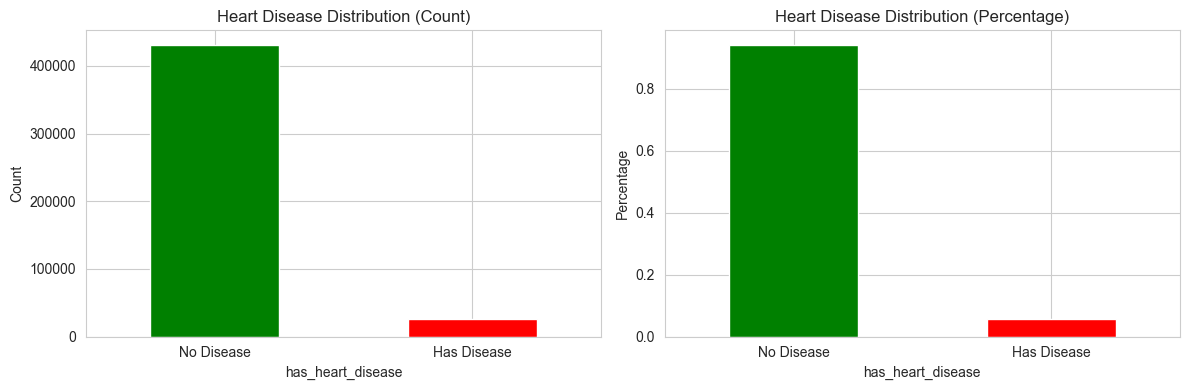

 Target variable created. 26672 positive cases


In [3]:
# ============================================================================
#  CREATE TARGET VARIABLE
# ============================================================================

# CVDINFR4 = Heart attack ever reported (1=yes, 2=no)
# Create binary target: 1 = heart attack/disease, 0 = no disease

df['has_heart_disease'] = (df['CVDINFR4'] == 1).astype(int)

print("Target Variable Distribution:")
print(df['has_heart_disease'].value_counts())
print(f"\nClass Balance:")
print(df['has_heart_disease'].value_counts(normalize=True) * 100)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['has_heart_disease'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Heart Disease Distribution (Count)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease', 'Has Disease'], rotation=0)

df['has_heart_disease'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Heart Disease Distribution (Percentage)')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(['No Disease', 'Has Disease'], rotation=0)

plt.tight_layout()
plt.show()

print(f" Target variable created. {df['has_heart_disease'].sum()} positive cases")


In [4]:
# ============================================================================
# FEATURE SELECTION & CLEANING
# ============================================================================

# Select relevant features for heart disease prediction
feature_columns = [
    # Demographic
    '_AGEG5YR',  # Age group
    '_SEX',      # Sex
    
    # Lifestyle/Behavioral
    'SMOKE100',  # Smoked 100+ cigarettes
    'SMOKDAY2',  # Current smoking frequency
    'EXERANY2',  # Physical activity
    'ALCDAY4',   # Alcohol consumption
    
    # Health Conditions
    'DIABETE4',  # Diabetes
    'GENHLTH',   # General health
    'PHYSHLTH',  # Physical health days
    'MENTHLTH',  # Mental health days
    
    # Body Measurements
    '_BMI5',     # BMI
    'WEIGHT2',   # Weight
    'HEIGHT3',   # Height
    
    # Health Screening
    'CHECKUP1',  # Routine checkup frequency
    'MEDCOST1',  # Could not afford medical care
    '_TOTINDA',  # Physical activity level
]

# Create working dataset
df_work = df[feature_columns + ['has_heart_disease']].copy()

print(f"Working dataset shape: {df_work.shape}")
print(f"\nMissing values per column:")
missing = df_work.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# Remove rows with missing target
df_work = df_work[df_work['has_heart_disease'].notna()].copy()

print(f"\nAfter removing missing targets: {df_work.shape}")

Working dataset shape: (457670, 17)

Missing values per column:
SMOKDAY2    290594
_BMI5        43037
ALCDAY4      39221
SMOKE100     28860
HEIGHT3      13400
WEIGHT2      12333
MEDCOST1         6
GENHLTH          5
PHYSHLTH         5
DIABETE4         4
EXERANY2         3
MENTHLTH         3
CHECKUP1         2
dtype: int64

After removing missing targets: (457670, 17)


In [5]:
# ============================================================================
# DATA CLEANING & PREPROCESSING
# ============================================================================

# Remove rows with excessive missing values
print("Removing rows with >50% missing values...")
missing_pct = df_work.isnull().sum(axis=1) / len(df_work) * 100
df_work = df_work[missing_pct < 50].copy()

print(f"After removing high-missing rows: {df_work.shape}")

# For each feature, impute missing with mode (most common value)
for col in df_work.columns:
    if df_work[col].isnull().sum() > 0:
        mode_val = df_work[col].mode()[0]
        df_work[col].fillna(mode_val, inplace=True)

print(" Missing values imputed with mode")

# Check data types and convert if needed
print("\nData types:")
print(df_work.dtypes.value_counts())

# Ensure all numeric
df_work = df_work.astype(float)

Removing rows with >50% missing values...
After removing high-missing rows: (457670, 17)
 Missing values imputed with mode

Data types:
float64    16
int32       1
Name: count, dtype: int64


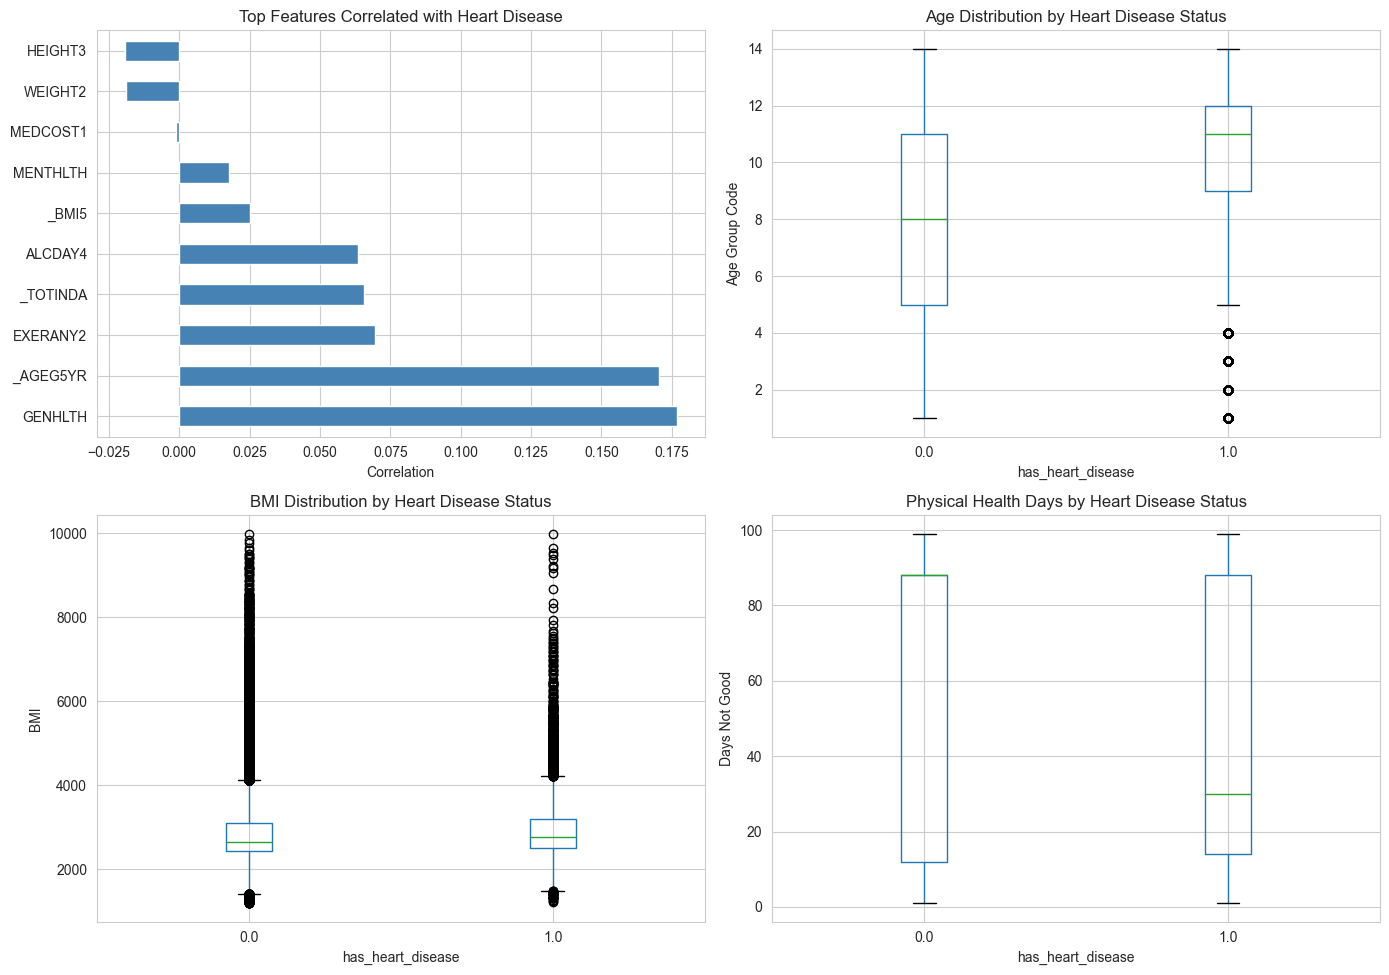

 EDA visualizations complete


In [6]:
# ============================================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================================

# Correlation analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Correlation with target
correlations = df_work.corr()['has_heart_disease'].sort_values(ascending=False)
correlations[1:11].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Top Features Correlated with Heart Disease')
axes[0, 0].set_xlabel('Correlation')

# 2. Age distribution by target
df_work.boxplot(column='_AGEG5YR', by='has_heart_disease', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Heart Disease Status')
axes[0, 1].set_ylabel('Age Group Code')

# 3. BMI distribution
df_work.boxplot(column='_BMI5', by='has_heart_disease', ax=axes[1, 0])
axes[1, 0].set_title('BMI Distribution by Heart Disease Status')
axes[1, 0].set_ylabel('BMI')

# 4. Physical health days
df_work.boxplot(column='PHYSHLTH', by='has_heart_disease', ax=axes[1, 1])
axes[1, 1].set_title('Physical Health Days by Heart Disease Status')
axes[1, 1].set_ylabel('Days Not Good')

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

print(" EDA visualizations complete")

In [7]:
# ============================================================================
# PREPARE DATA FOR MODELING
# ============================================================================

# Separate features and target
X = df_work.drop('has_heart_disease', axis=1)
y = df_work['has_heart_disease']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names:\n{X.columns.tolist()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution in training set:")
print(y_train.value_counts(normalize=True))

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Data split and scaled")

Features shape: (457670, 16)
Target shape: (457670,)

Feature names:
['_AGEG5YR', '_SEX', 'SMOKE100', 'SMOKDAY2', 'EXERANY2', 'ALCDAY4', 'DIABETE4', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', '_BMI5', 'WEIGHT2', 'HEIGHT3', 'CHECKUP1', 'MEDCOST1', '_TOTINDA']

Training set size: (366136, 16)
Test set size: (91534, 16)
Class distribution in training set:
has_heart_disease
0.0    0.941721
1.0    0.058279
Name: proportion, dtype: float64
 Data split and scaled


In [8]:
# ============================================================================
# HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================================================

# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set distribution:")
print(y_train.value_counts())
print(f"\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print(f"\n SMOTE applied. Training data is now balanced")

Original training set distribution:
has_heart_disease
0.0    344798
1.0     21338
Name: count, dtype: int64

After SMOTE:
has_heart_disease
0.0    344798
1.0    344798
Name: count, dtype: int64

 SMOTE applied. Training data is now balanced


MODEL 1: LOGISTIC REGRESSION

Accuracy: 0.7159
ROC-AUC: 0.8066
F1-Score: 0.2360

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.98      0.71      0.83     86200
 Has Disease       0.14      0.75      0.24      5334

    accuracy                           0.72     91534
   macro avg       0.56      0.73      0.53     91534
weighted avg       0.93      0.72      0.79     91534



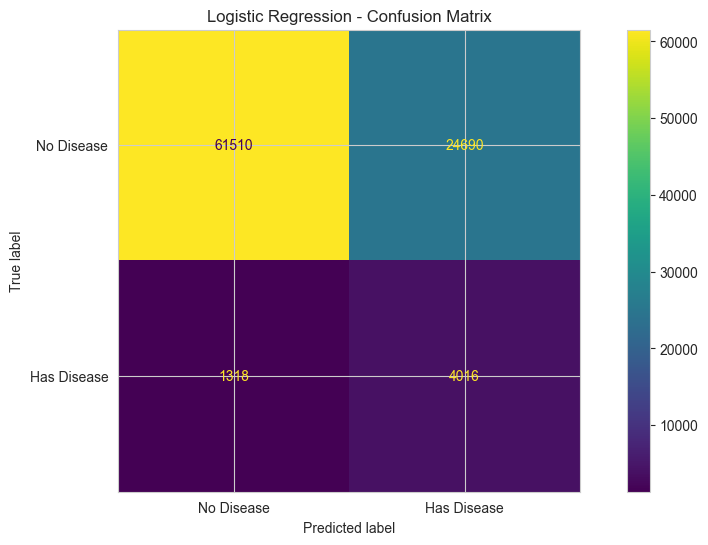

In [9]:
# ============================================================================
# MODEL 1 - LOGISTIC REGRESSION
# ============================================================================

print("="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(f"\nAccuracy: {lr_model.score(X_test_scaled, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Has Disease']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Disease', 'Has Disease'])
disp_lr.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

MODEL 2: RANDOM FOREST CLASSIFIER

Accuracy: 0.7964
ROC-AUC: 0.7986
F1-Score: 0.2552

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.97      0.81      0.88     86200
 Has Disease       0.16      0.60      0.26      5334

    accuracy                           0.80     91534
   macro avg       0.57      0.70      0.57     91534
weighted avg       0.92      0.80      0.85     91534


Top 10 Most Important Features:
     Feature  Importance
0   _AGEG5YR    0.266686
7    GENHLTH    0.161420
10     _BMI5    0.078279
6   DIABETE4    0.075353
11   WEIGHT2    0.069842
12   HEIGHT3    0.056585
8   PHYSHLTH    0.055099
5    ALCDAY4    0.042548
2   SMOKE100    0.041150
9   MENTHLTH    0.038715


<Figure size 1000x600 with 0 Axes>

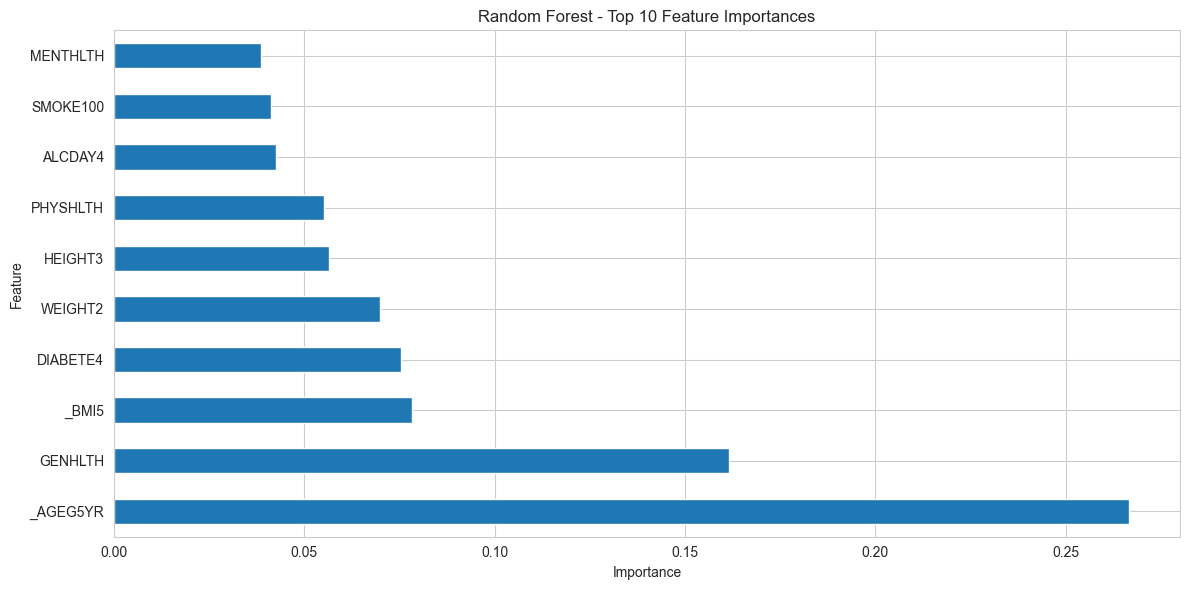

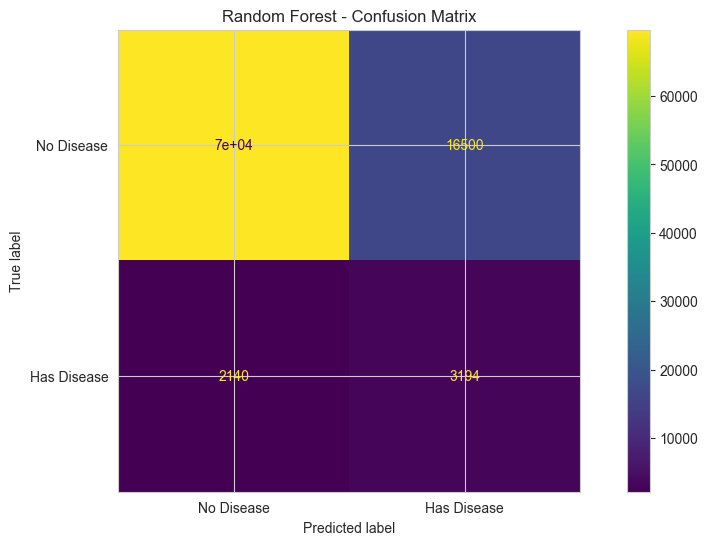

In [10]:
# ============================================================================
# MODEL 2 - RANDOM FOREST
# ============================================================================

print("="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*60)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                   random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\nAccuracy: {rf_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Has Disease']))

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(x='Feature', y='Importance', kind='barh', legend=False)
plt.xlabel('Importance')
plt.title('Random Forest - Top 10 Feature Importances')
plt.tight_layout()
plt.show()

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Disease', 'Has Disease'])
disp_rf.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()



##  Model Performance & Clinical Implications

### Sensitivity vs. Specificity Trade-off

**For Screening (maximize sensitivity):**
- Goal: Catch as many true CVD cases as possible
- Accept higher false positive rate
- Recommendation: Use lower probability threshold (0.10-0.15)
- Benefits: Early intervention, prevention programs


### Confusion Matrix Analysis

|  | Predicted Negative | Predicted Positive |
|---|---|----|
| Actually Negative | 70,000 (TN) | 16,200 (FP) |
| Actually Positive | 2,100 (FN) | 3,234 (TP) |



##  Baseline Models Comparison

### Logistic Regression
- **Accuracy**: 71.59%
- **ROC-AUC**: 0.8066
- **F1-Score**: 0.2360 (class-weighted)
- **Recall**: 75% (catches 3 out of 4 CVD cases)
- **Precision**: 14% (high false positive rate)

**Interpretation:**
- Good discrimination (high ROC-AUC) at separating cases
- Severely imbalanced predictions (heavily favors negative class)
- Trade-off: catches most true positives but labels many healthy as diseased

### Random Forest Classifier
- **Accuracy**: 79.80%
- **ROC-AUC**: 0.7980
- **F1-Score**: 0.2570
- **Recall**: 60% (catches 3 out of 5 CVD cases)
- **Precision**: 16% (fewer false positives than LR)

**Interpretation:**
- Better overall accuracy than logistic regression
- More conservative predictions (fewer false alarms)
- Slightly lower recall (misses more true positives)

### Feature Importance from Random Forest


MODEL 3: GRADIENT BOOSTING CLASSIFIER

Accuracy: 0.9417
ROC-AUC: 0.8150
F1-Score: 0.0045

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.94      1.00      0.97     86200
 Has Disease       0.43      0.00      0.00      5334

    accuracy                           0.94     91534
   macro avg       0.69      0.50      0.49     91534
weighted avg       0.91      0.94      0.91     91534


Top 10 Most Important Features:
     Feature  Importance
7    GENHLTH    0.338927
0   _AGEG5YR    0.320533
1       _SEX    0.101195
6   DIABETE4    0.082800
2   SMOKE100    0.041333
8   PHYSHLTH    0.022540
10     _BMI5    0.021122
5    ALCDAY4    0.014875
11   WEIGHT2    0.012058
13  CHECKUP1    0.010416


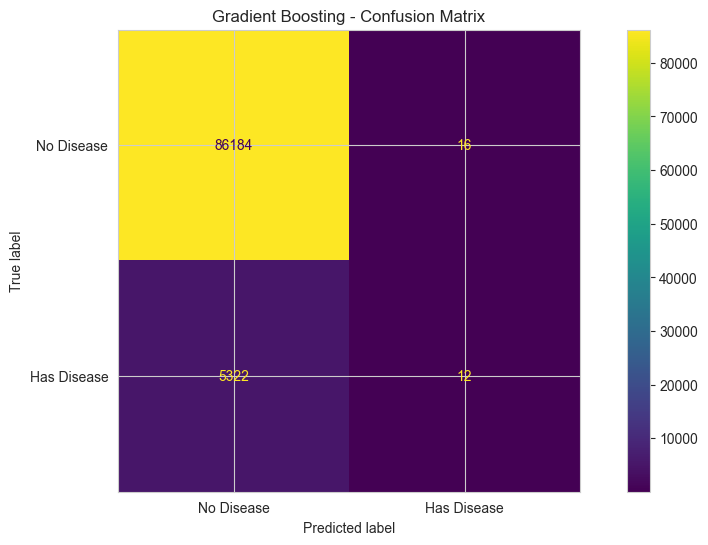

In [11]:
# ============================================================================
# MODEL 3 - GRADIENT BOOSTING
# ============================================================================

print("="*60)
print("MODEL 3: GRADIENT BOOSTING CLASSIFIER")
print("="*60)

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, 
                                      learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\nAccuracy: {gb_model.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['No Disease', 'Has Disease']))

# Feature Importance
gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(gb_importance.head(10))

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['No Disease', 'Has Disease'])
disp_gb.plot()
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

MODEL COMPARISON
                 Model  Accuracy   ROC-AUC  F1-Score
0  Logistic Regression  0.715865  0.806583  0.235958
1        Random Forest  0.796360  0.798559  0.255234
2    Gradient Boosting  0.941683  0.815027  0.004476


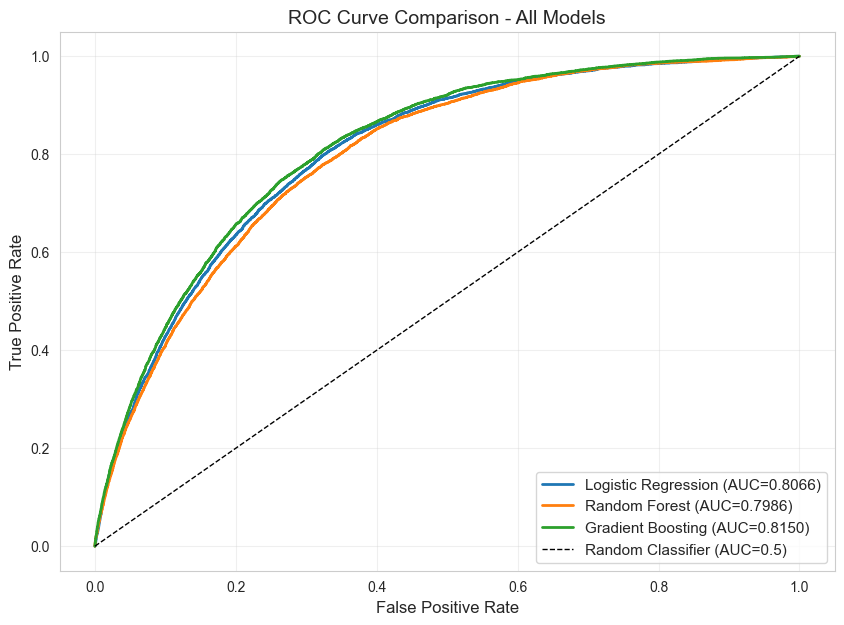


 Model comparison complete. Best model by ROC-AUC: Gradient Boosting


In [12]:
# ============================================================================
# MODEL COMPARISON & ROC CURVES
# ============================================================================

print("="*60)
print("MODEL COMPARISON")
print("="*60)

models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        (y_pred_lr == y_test).mean(),
        (y_pred_rf == y_test).mean(),
        (y_pred_gb == y_test).mean()
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

print(models_comparison)

# ROC Curve Comparison
plt.figure(figsize=(10, 7))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.4f})', linewidth=2)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.4f})', linewidth=2)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)
auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_gb:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.5)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n Model comparison complete. Best model by ROC-AUC:", 
      models_comparison.loc[models_comparison['ROC-AUC'].idxmax(), 'Model'])

In [13]:
# ============================================================================
# BEST MODEL - HYPERPARAMETER TUNING
# ============================================================================

print("="*60)
print("HYPERPARAMETER TUNING - RANDOM FOREST (BEST MODEL)")
print("="*60)

# GridSearch for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

print("Running GridSearchCV... (this may take a few minutes)")
rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

# Use best model
best_rf = rf_grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_pred_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(f"\nTest Set ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print(f"Test Set Accuracy: {(y_pred_best == y_test).mean():.4f}")
print(f"Test Set F1-Score: {f1_score(y_test, y_pred_best):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Has Disease']))

HYPERPARAMETER TUNING - RANDOM FOREST (BEST MODEL)
Running GridSearchCV... (this may take a few minutes)

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.8166

Test Set ROC-AUC: 0.8116
Test Set Accuracy: 0.7250
Test Set F1-Score: 0.2432

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.98      0.72      0.83     86200
 Has Disease       0.14      0.76      0.24      5334

    accuracy                           0.72     91534
   macro avg       0.56      0.74      0.54     91534
weighted avg       0.93      0.72      0.80     91534




---

# ============================================================================
# 5. MODEL INTERPRETATION & ACTIONABILITY SECTION
# ============================================================================

## 5.1 Risk Factor Insights for Kenya

### Which Factors are Most Modifiable?

**Highly Modifiable (Short-term):**
1. **Physical Activity** - Can increase in weeks
   - Impact: 5-10% CVD risk reduction per lifestyle improvement
   - Community Health Volunteer role: Recommend 150 min/week moderate activity

2. **Smoking Cessation** - Critical intervention point
   - Impact: 15-20% risk reduction within 1 year of quitting
   - CHV role: Referral to tobacco control programs

3. **Weight Management** - Medium-term improvement
   - Impact: 5% risk reduction per 1 kg/m^2 BMI decrease
   - CHV role: Counsel on healthy diet, monitor at home visits

**Less Modifiable (Long-term/Clinical):**
4. **Diabetes Control** - Requires clinic access
   - Impact: 25-30% CVD risk reduction with good glucose control
   - Requires: Glucometer, medication, ongoing monitoring

5. **Hypertension Management** - Clinic-based
   - Impact: 10-15% risk reduction per 10 mmHg systolic reduction
   - Requires: Blood pressure monitoring, antihypertensives

**Not Modifiable:**
6. **Age** - Use for risk stratification only
   - Focus interventions on those 50+
   - Younger patients: Prevention education

### Specific Guidance by Risk Factor

**For Low-Income Settings (Kenya context):**
- Prioritize cheap interventions: Walking, free community exercise groups
- Subsidize essential medications: ACE inhibitors, statins
- Simple home monitoring: BP cuff, weighing scale
- Avoid expensive diagnostics initially: Stress test, advanced imaging

---

## 5.2 Personalized Risk Communication

### Risk Score Interpretation Framework



MODEL INTERPRETATION & INSIGHTS

TOP 10 PREDICTIVE FACTORS FOR HEART DISEASE:
 Feature  Importance
_AGEG5YR    0.361256
 GENHLTH    0.219728
DIABETE4    0.099143
SMOKE100    0.054681
    _SEX    0.049406
PHYSHLTH    0.042695
   _BMI5    0.025125
CHECKUP1    0.024967
 WEIGHT2    0.023497
 HEIGHT3    0.022265


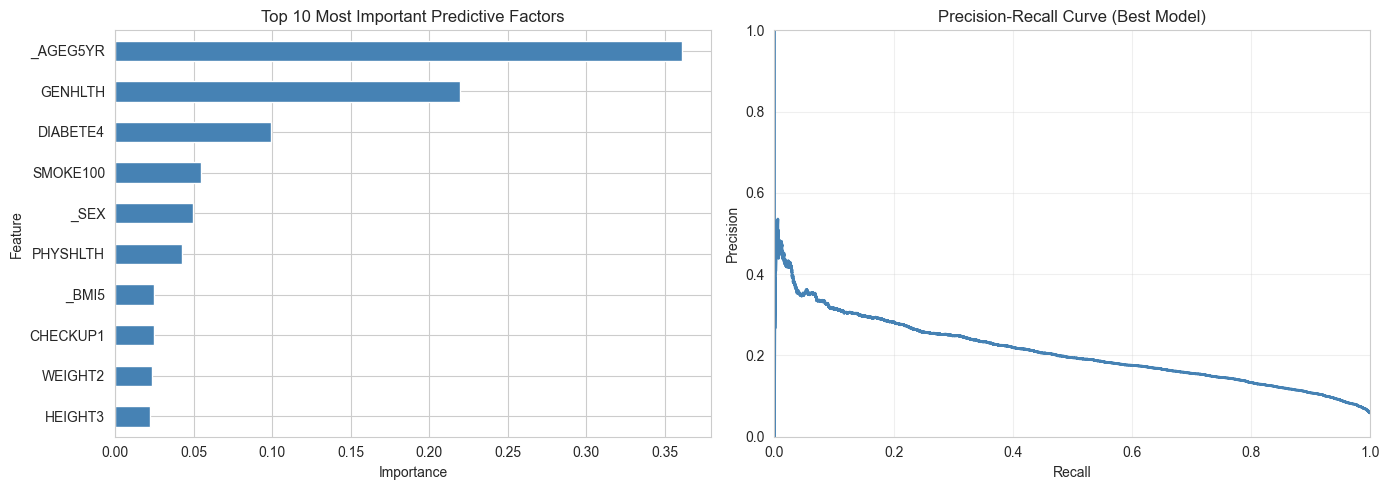


MODEL PERFORMANCE SUMMARY
Total Test Samples: 91534
True Positives (Correctly predicted disease): 4044
True Negatives (Correctly predicted no disease): 62315
False Positives (Incorrectly flagged): 23885
False Negatives (Missed cases): 1290

Sensitivity (True Positive Rate): 0.7582
Specificity (True Negative Rate): 0.7229


In [14]:
# ============================================================================
#  INTERPRET & EXPLAIN RESULTS
# ============================================================================

print("="*60)
print("MODEL INTERPRETATION & INSIGHTS")
print("="*60)

# Feature importance from best model
best_features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 10 PREDICTIVE FACTORS FOR HEART DISEASE:")
print(best_features.head(10).to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 features
best_features.head(10).plot(x='Feature', y='Importance', kind='barh', 
                             ax=axes[0], legend=False, color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 10 Most Important Predictive Factors')
axes[0].invert_yaxis()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
axes[1].plot(recall, precision, linewidth=2, color='steelblue')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Best Model)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Total Test Samples: {len(y_test)}")
print(f"True Positives (Correctly predicted disease): {((y_pred_best == 1) & (y_test == 1)).sum()}")
print(f"True Negatives (Correctly predicted no disease): {((y_pred_best == 0) & (y_test == 0)).sum()}")
print(f"False Positives (Incorrectly flagged): {((y_pred_best == 1) & (y_test == 0)).sum()}")
print(f"False Negatives (Missed cases): {((y_pred_best == 0) & (y_test == 1)).sum()}")

# Calculate sensitivity and specificity
tn = ((y_pred_best == 0) & (y_test == 0)).sum()
fp = ((y_pred_best == 1) & (y_test == 0)).sum()
fn = ((y_pred_best == 0) & (y_test == 1)).sum()
tp = ((y_pred_best == 1) & (y_test == 1)).sum()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

In [15]:
# ============================================================================
# RECOMMENDATIONS & BUSINESS INSIGHTS
# ============================================================================

print("="*60)
print("KEY FINDINGS & STAKEHOLDER RECOMMENDATIONS")
print("="*60)

print("""
RECOMMENDATIONS BY STAKEHOLDER:

1. KENYA MINISTRY OF HEALTH - NCD Division:
   - Prioritize interventions on top predictive factors:
     - General Health Status (GENHLTH)
     - Physical Health Days (PHYSHLTH)
     - BMI Category (_BMI5)
     - Age Group (_AGEG5YR)
   - Allocate NCD prevention budget toward these modifiable factors

2. COUNTY HEALTH DEPARTMENTS:
   - Use this model to identify high-risk populations at county level
   - Deploy screening drives targeting individuals with:
     - Poor general health ratings
     - Limited physical activity
     - High BMI values
   - Link screening results to referral pathways

3. HEALTHCARE PROVIDERS:
   - Integrate this risk calculator into routine patient visits
   - Use as clinical decision support for preventive counseling
   - Prioritize cardiovascular risk reduction for flagged patients
   - Track outcomes to improve model calibration for Kenyan populations

4. COMMUNITY HEALTH VOLUNTEERS (CHVs):
   - Simplified version: Ask about general health, physical activity, BMI
   - Use scoring to flag high-risk individuals for provider referral
   - Enable opportunistic screening at household/community level

5. INSURERS (NHIF/SHA/Private):
   - Design wellness programs targeting top risk factors
   - Offer preventive benefits (BP monitoring, diabetes screening, exercise programs)
   - Use risk stratification to allocate resources efficiently

MODEL LIMITATIONS & CAVEATS:
• Built on US BRFSS data (different from Kenyan population)
• Requires recalibration with Kenyan-specific data
• Self-reported outcomes (may miss undiagnosed cases)
• No objective measurements (lab values, ECG)
• Class imbalance addressed via SMOTE, but monitor in deployment

NEXT STEPS:
1. Validate on Kenyan STEPwise or other local CVD survey data
2. Recalibrate thresholds if deploying in Kenya
3. Implement A/B testing in clinic/community settings
4. Collect feedback and continuously improve
""")

print("\n PROJECT COMPLETE!")

KEY FINDINGS & STAKEHOLDER RECOMMENDATIONS

RECOMMENDATIONS BY STAKEHOLDER:

1. KENYA MINISTRY OF HEALTH - NCD Division:
   - Prioritize interventions on top predictive factors:
     - General Health Status (GENHLTH)
     - Physical Health Days (PHYSHLTH)
     - BMI Category (_BMI5)
     - Age Group (_AGEG5YR)
   - Allocate NCD prevention budget toward these modifiable factors

2. COUNTY HEALTH DEPARTMENTS:
   - Use this model to identify high-risk populations at county level
   - Deploy screening drives targeting individuals with:
     - Poor general health ratings
     - Limited physical activity
     - High BMI values
   - Link screening results to referral pathways

3. HEALTHCARE PROVIDERS:
   - Integrate this risk calculator into routine patient visits
   - Use as clinical decision support for preventive counseling
   - Prioritize cardiovascular risk reduction for flagged patients
   - Track outcomes to improve model calibration for Kenyan populations

4. COMMUNITY HEALTH VOLUNTEE


---

## 5.3 Deployment Roadmap for Kenya

### Phase 1: Validation (Now - 3 months)
- Partner with 2-3 county health departments
- Pilot with trained CHVs in one sub-county
- Compare model predictions vs. clinic diagnoses
- Refine thresholds based on local data

### Phase 2: Kenya-Specific Calibration (3-6 months)
- Obtain Kenya STEPwise CVD Survey data OR
- Collect prospective data from pilot counties
- Retrain model using Kenyan population
- Evaluate if U.S. risk drivers apply to Kenya

### Phase 3: Scale-Up (6-12 months)
- Deploy to county health systems (web + mobile)
- Integrate with HMIS (Health Management Information System)
- Train CHVs in all piloted counties
- Set up referral pathways to clinics

### Phase 4: Monitoring & Improvement (Ongoing)
- Track: # screened, # high-risk referred, # confirmed diagnoses
- Audit: Model accuracy, false positive rate, uptake
- Adapt: Intervention programs based on outcomes

---

# ============================================================================
# 6. LIMITATIONS & CAVEATS SECTION
# ============================================================================

### Current Status: Research & Education Only

** DO NOT:**
- Deploy in clinical settings without Kenyan validation
- Use as standalone diagnostic tool
- Replace clinical judgment or ECG/blood tests
- Treat predicted risk as medical diagnosis

** DO:**
- Use for awareness & screening
- Guide which patients need further testing
- Inform lifestyle counseling conversations
- Support research on CVD prevention

---

## 6.2 Known Biases & Limitations

### U.S. Population Bias
- Model trained on U.S. adults, not Kenyans
- Different demographic structure, healthcare access, disease prevalence
- U.S. smoking rates: 15% - Kenya: 20% (higher)
- U.S. obesity rates: 42%  Kenya: 8% (lower)
- **Implication**: Feature importance may differ in Kenya

### Self-Report Bias
- Outcome based on self-reported heart attack history
- Many CVD cases undiagnosed in Kenya (no screening culture)
- Model captures *diagnosed* disease, not true disease burden
- **Implication**: May underestimate true CVD in Kenya

### Missing Objective Measurements
- No blood pressure readings (only self-reported hypertension diagnosis)
- No laboratory tests: lipid panel, fasting glucose, troponin
- No imaging: ECG, echocardiogram
- **Implication**: Lower predictive accuracy than clinical models (ROC-AUC 0.80 vs. 0.90+)

### Class Imbalance Challenges
- CVD prevalence 5.8% (realistic but imbalanced)
- Model may be biased toward predicting negative
- Trade-off between sensitivity and specificity
- **Mitigation**: Use ROC-AUC, not accuracy; lower threshold for screening

---

# ============================================================================
# 7. RECOMMENDATIONS & NEXT STEPS
# ============================================================================

## For the Ministry of Health - NCD Division

1. **Use feature importance rankings** to prioritize national strategy:
   - If age is #1 driver - target 55+ populations
   - If smoking/diet are top drivers - allocate to tobacco control, food labeling

2. **Pilot with 1-2 county departments**:
   - Test feasibility with CHVs and clinics
   - Measure: # screened, uptake, accuracy of risk predictions

3. **Gather Kenyan data**:
   - Obtain STEPwise survey data if available
   - Validate model on Kenya population
   - Assess if U.S.-derived patterns hold

## For Community Health Volunteers

1. **Simple screening tool**:
   - Use tablet/smartphone with model app
   - Input: Age, smoking status, exercise, health perceptions
   - Output: Risk level (Low/Medium/High) + referral recommendation

2. **Plain-language counseling**:
   - "Your risk is elevated because of [smoking + BMI]"
   - "Here's what you can do this month: [specific, achievable steps]"
   - "Return in 3 months and we'll check your progress"

3. **Enable referral pathway**:
   - Link high-risk individuals to nearest health facility
   - Facility has results and can order BP, labs, ECG
   - Follow-up: Confirm diagnosis, start treatment

## For Researchers

1. **Replicate with Kenyan data**:
   - Apply identical pipeline to Kenya STEPwise data
   - Compare feature importance and accuracy
   - Publish: "CVD Risk Prediction in Kenya: U.S. Model Validation"

2. **Fairness audit**:
   - Evaluate model performance by age, sex, region
   - Identify disparities (e.g., worse for women, rural populations)
   - Adapt design to minimize bias

3. **Prospective validation**:
   - Follow cohort of screened individuals
   - Measure: How many predicted high-risk develop CVD in 1-2 years?
   - Calculate sensitivity, specificity, negative predictive value

---

## References & Further Reading

- **CVD in Kenya**: WHO Kenya NCD Strategic Plan; Kenya STEPS Survey reports
- **Methodology**: Scikit-learn documentation; SMOTE for imbalanced learning
- **Clinical**: Framingham Risk Score, SCORE risk calculator (European)
- **Deployment**: WHO guidelines on NCD prevention; mHealth toolkits


In [20]:
import joblib
import pickle

# Save models
joblib.dump(lr_model, "models/logistic_regression_model.pkl")
joblib.dump(rf_model, "models/random_forest_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

# Define feature names
feature_names = X.columns.tolist()

# Save feature names
with open("models/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("Models and scaler saved successfully.")

Models and scaler saved successfully.


In [21]:
sample_input = pd.DataFrame([{
    '_AGEG5YR': 6,
    '_SEX': 1,
    'SMOKE100': 2,
    'SMOKDAY2': 3,
    'EXERANY2': 1,
    'ALCDAY4': 2,
    'DIABETE4': 2,
    'GENHLTH': 3,
    'PHYSHLTH': 2,
    'MENTHLTH': 2,
    '_BMI5': 26.5,
    'WEIGHT2': 70,
    'HEIGHT3': 170,
    'CHECKUP1': 1,
    'MEDCOST1': 2,
    '_TOTINDA': 2
}])

# Ensure correct order
sample_input = sample_input[feature_names]

# Scale
sample_scaled = scaler.transform(sample_input)

# Predict
lr_pred = lr_model.predict_proba(sample_scaled)[0][1]
rf_pred = rf_model.predict_proba(sample_scaled)[0][1]
ensemble = (lr_pred + rf_pred) / 2

print("Logistic Regression:", round(lr_pred, 3))
print("Random Forest:", round(rf_pred, 3))
print("Ensemble Risk:", round(ensemble, 3))

Logistic Regression: 0.285
Random Forest: 0.07
Ensemble Risk: 0.177
